In [7]:
# importing libraries

import numpy as np
import matplotlib.pyplot as plt

Homework 4, problem 4, part c

In [8]:
def simulate_conditioned_paths(num_simulations=10000):
    P = np.array([
        [0.0, 0.625, 1.0, 1.0],  # U
        [0.2, 0.2,   0.2, 1.0],  # I
        [1.0, 1.0,   1.0, 1.0],  # M
        [0.0, 0.0,   0.0, 1.0]   # F
    ])
    
    current_states = np.ones(num_simulations, dtype = int)
    steps = np.zeros(num_simulations, dtype = int)
    active = np.ones(num_simulations, dtype = bool)
    
    while np.any(active):
        num_active = np.sum(active)
        u = np.random.rand(num_active)
        thresholds = P[current_states[active]]
        next_states = np.argmax(u[:, None] < thresholds, axis=1)
        
        current_states[active] = next_states
        steps[active] += 1
        active = (current_states != 3)
        
    return steps

In [13]:
np.random.seed(42)
path_lengths = simulate_conditioned_paths(10000)

empirical_mean = np.mean(path_lengths)
unique_lengths = np.unique(path_lengths)

print(f"Empirical Mean Steps: {empirical_mean:.4f}")
print("Theoretical: 1.8")
print(f"Unique Path Lengths Sampled: {unique_lengths}")

A = np.array([
    [0.0, 0.625, 0.375],  # U
    [0.2, 0.0,   0.0],    # I
    [1.0, 0.0,   0.0]     # M
])

absorption = np.array([0.0, 0.8, 0.0]) # Transition vector
alpha = np.array([0.0, 1.0, 0.0]) # Initial state vector

max_plot_steps = 11
theoretical_steps = np.arange(1, max_plot_steps + 1)
theoretical_probs = []

current_dist = alpha.copy()
for n in range(1, max_plot_steps + 1):
    prob_absorb = np.dot(current_dist, absorption)
    theoretical_probs.append(prob_absorb.item()) 
    current_dist = np.dot(current_dist, A)

Empirical Mean Steps: 1.8298
Theoretical: 1.8
Unique Path Lengths Sampled: [ 1  3  5  7  9 11 13 15 17 19 21 23 25 27 31]


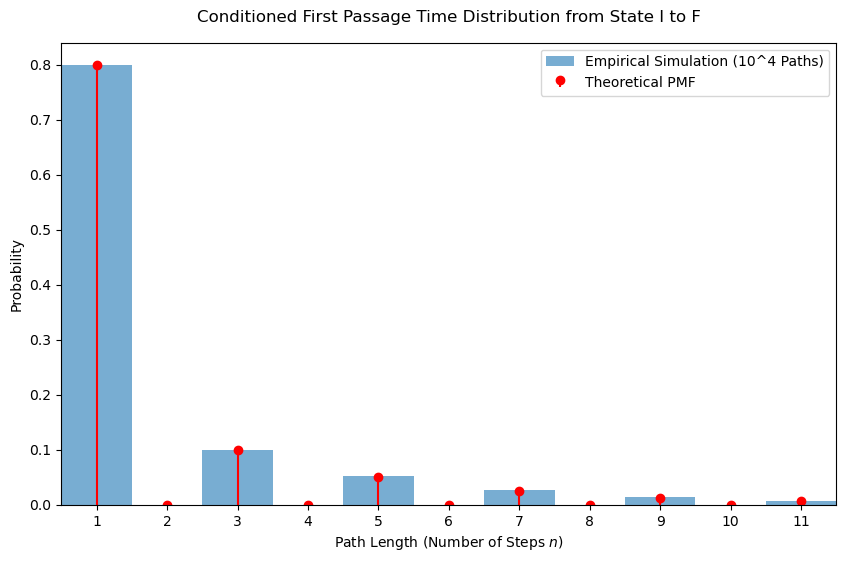

In [12]:
plt.figure(figsize = (10, 6))

bins = np.arange(0.5, max_plot_steps + 1.5, 1)
plt.hist(path_lengths, bins = bins, density = True, alpha = 0.6, label='Empirical Simulation (10^4 Paths)')

plt.stem(theoretical_steps, theoretical_probs, linefmt='r-', markerfmt='ro', basefmt=' ', label='Theoretical PMF')

plt.title('Conditioned First Passage Time Distribution from State I to F', pad=15)
plt.xlabel('Path Length (Number of Steps $n$)')
plt.ylabel('Probability')

plt.xticks(np.arange(1, max_plot_steps + 1))
plt.xlim(0.5, max_plot_steps + 0.5)

plt.legend()
plt.show()